In [5]:
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score,confusion_matrix
from keras.models import Sequential
from keras.layers import Dense, Dropout,Conv2D,MaxPooling2D,Flatten,BatchNormalization
from keras.datasets import cifar10
from keras.callbacks import EarlyStopping
import warnings
warnings.filterwarnings('ignore')

In [6]:
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

array([[[ 59,  62,  63],
        [ 43,  46,  45],
        [ 50,  48,  43],
        ...,
        [158, 132, 108],
        [152, 125, 102],
        [148, 124, 103]],

       [[ 16,  20,  20],
        [  0,   0,   0],
        [ 18,   8,   0],
        ...,
        [123,  88,  55],
        [119,  83,  50],
        [122,  87,  57]],

       [[ 25,  24,  21],
        [ 16,   7,   0],
        [ 49,  27,   8],
        ...,
        [118,  84,  50],
        [120,  84,  50],
        [109,  73,  42]],

       ...,

       [[208, 170,  96],
        [201, 153,  34],
        [198, 161,  26],
        ...,
        [160, 133,  70],
        [ 56,  31,   7],
        [ 53,  34,  20]],

       [[180, 139,  96],
        [173, 123,  42],
        [186, 144,  30],
        ...,
        [184, 148,  94],
        [ 97,  62,  34],
        [ 83,  53,  34]],

       [[177, 144, 116],
        [168, 129,  94],
        [179, 142,  87],
        ...,
        [216, 184, 140],
        [151, 118,  84],
        [123,  92,  72]]], dtype=uint8)
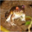

In [7]:
X_train[0]

In [19]:
model = Sequential([
    # Block 1
    Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
    BatchNormalization(),
    Conv2D(32, (3,3), activation='relu', padding='same'),
    MaxPooling2D(2,2),
    Dropout(0.25),

    # Block 2
    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(64, (3,3), activation='relu', padding='same'),
    MaxPooling2D(2,2),
    Dropout(0.20),

    # Block 3
    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(128, (3,3), activation='relu', padding='same'),
    MaxPooling2D(2,2),
    Dropout(0.20),

    Conv2D(256, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(256, (3,3), activation='relu', padding='same'),
    MaxPooling2D(2,2),
    Dropout(0.2),
    # Classifier
    Flatten(),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

In [20]:
model.compile(optimizer='adam',loss="SparseCategoricalCrossentropy",metrics=['accuracy'])

In [21]:
model.fit(X_train,y_train,epochs=50,validation_data=(X_test,y_test),callbacks=[EarlyStopping(patience=3)])

Epoch 1/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 42s 16ms/step - accuracy: 0.2767 - loss: 2.0071 - val_accuracy: 0.4414 - val_loss: 1.4662
Epoch 2/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.4874 - loss: 1.4272 - val_accuracy: 0.5558 - val_loss: 1.3126
Epoch 3/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.5890 - loss: 1.1882 - val_accuracy: 0.6266 - val_loss: 1.0777
Epoch 4/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.6465 - loss: 1.0523 - val_accuracy: 0.6753 - val_loss: 0.9225
Epoch 5/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.6898 - loss: 0.9369 - val_accuracy: 0.6809 - val_loss: 0.9148
Epoch 6/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.7224 - loss: 0.8510 - val_accuracy: 0.7531 - val_loss: 0.7322
Epoch 7/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.7496 - loss: 0.7859 - val_accuracy: 0.7408 - val_loss: 0.7796
Epoch 8/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.7720 - loss: 

In [22]:
y_pred_probs = model.predict(X_test)
y_prd = np.argmax(y_pred_probs, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step


In [23]:
accuracy_score(y_test,y_prd)

0.8423